In [1]:
import pandas as pd
path = "dataMissingValue.csv"
df = pd.read_csv(path)
df

,Name,School Level,Blood Type,Age,Fav Fruit,Shoe Chart
0,A,High School,AB,15.0,apple,36.0
1,B,High School,NaN,17.0,banana,41.0
2,C,High School,NaN,NaN,watermelon,NaN
3,D,High School,NaN,16.0,NaN,38.0
4,E,Middle School,B,15.0,banana,37.0
5,F,Middle School,NaN,14.0,grapes,NaN
6,G,Middle School,O,NaN,mango,36.0
7,H,High School,A,16.0,papaya,39.0
8,I,High School,NaN,18.0,NaN,40.0
9,J,Middle School,NaN,NaN,avocado,35.0


In [2]:
df.isnull().sum()

Name            0
School Level    0
Blood Type      6
Age             3
Fav Fruit       2
Shoe Chart      2
dtype: int64

In [3]:
percent_missing = 100*df.isnull().mean()
percent_missing

Name             0.0
School Level     0.0
Blood Type      60.0
Age             30.0
Fav Fruit       20.0
Shoe Chart      20.0
dtype: float64

In [4]:
df.dropna(axis=0)

,Name,School Level,Blood Type,Age,Fav Fruit,Shoe Chart
0,A,High School,AB,15.0,apple,36.0
4,E,Middle School,B,15.0,banana,37.0
7,H,High School,A,16.0,papaya,39.0


In [5]:
df.dropna(axis=1)

,Name,School Level
0,A,High School
1,B,High School
2,C,High School
3,D,High School
4,E,Middle School
5,F,Middle School
6,G,Middle School
7,H,High School
8,I,High School
9,J,Middle School


In [6]:
df.dropna(thresh=5)

,Name,School Level,Blood Type,Age,Fav Fruit,Shoe Chart
0,A,High School,AB,15.0,apple,36.0
1,B,High School,NaN,17.0,banana,41.0
4,E,Middle School,B,15.0,banana,37.0
6,G,Middle School,O,NaN,mango,36.0
7,H,High School,A,16.0,papaya,39.0


In [7]:
df.dropna(subset=['Age'])

,Name,School Level,Blood Type,Age,Fav Fruit,Shoe Chart
0,A,High School,AB,15.0,apple,36.0
1,B,High School,NaN,17.0,banana,41.0
3,D,High School,NaN,16.0,NaN,38.0
4,E,Middle School,B,15.0,banana,37.0
5,F,Middle School,NaN,14.0,grapes,NaN
7,H,High School,A,16.0,papaya,39.0
8,I,High School,NaN,18.0,NaN,40.0


In [8]:
df_drop = df.drop(columns = 'Blood Type')
df_drop

,Name,School Level,Age,Fav Fruit,Shoe Chart
0,A,High School,15.0,apple,36.0
1,B,High School,17.0,banana,41.0
2,C,High School,NaN,watermelon,NaN
3,D,High School,16.0,NaN,38.0
4,E,Middle School,15.0,banana,37.0
5,F,Middle School,14.0,grapes,NaN
6,G,Middle School,NaN,mango,36.0
7,H,High School,16.0,papaya,39.0
8,I,High School,18.0,NaN,40.0
9,J,Middle School,NaN,avocado,35.0


In [9]:
df_filled = df_drop.copy()
df_filled['Age'] = df['Age'].fillna(df['Age'].mean())
df_filled

,Name,School Level,Age,Fav Fruit,Shoe Chart
0,A,High School,15.000000,apple,36.0
1,B,High School,17.000000,banana,41.0
2,C,High School,15.857143,watermelon,NaN
3,D,High School,16.000000,NaN,38.0
4,E,Middle School,15.000000,banana,37.0
5,F,Middle School,14.000000,grapes,NaN
6,G,Middle School,15.857143,mango,36.0
7,H,High School,16.000000,papaya,39.0
8,I,High School,18.000000,NaN,40.0
9,J,Middle School,15.857143,avocado,35.0


In [10]:
df_filled['Shoe Chart'] = df['Shoe Chart'].fillna(df['Shoe Chart'].median())
df_filled

,Name,School Level,Age,Fav Fruit,Shoe Chart
0,A,High School,15.000000,apple,36.0
1,B,High School,17.000000,banana,41.0
2,C,High School,15.857143,watermelon,37.5
3,D,High School,16.000000,NaN,38.0
4,E,Middle School,15.000000,banana,37.0
5,F,Middle School,14.000000,grapes,37.5
6,G,Middle School,15.857143,mango,36.0
7,H,High School,16.000000,papaya,39.0
8,I,High School,18.000000,NaN,40.0
9,J,Middle School,15.857143,avocado,35.0


In [11]:
df_filled['Fav Fruit'] = df['Fav Fruit'].fillna(df['Fav Fruit'].mode().iloc[0])
df_filled

,Name,School Level,Age,Fav Fruit,Shoe Chart
0,A,High School,15.000000,apple,36.0
1,B,High School,17.000000,banana,41.0
2,C,High School,15.857143,watermelon,37.5
3,D,High School,16.000000,banana,38.0
4,E,Middle School,15.000000,banana,37.0
5,F,Middle School,14.000000,grapes,37.5
6,G,Middle School,15.857143,mango,36.0
7,H,High School,16.000000,papaya,39.0
8,I,High School,18.000000,banana,40.0
9,J,Middle School,15.857143,avocado,35.0


In [12]:
df_filled2 = df_drop.copy()
df_filled2['Shoe Chart'] = df_filled2['Shoe Chart'].replace("", None).bfill()
df_filled2

,Name,School Level,Age,Fav Fruit,Shoe Chart
0,A,High School,15.0,apple,36.0
1,B,High School,17.0,banana,41.0
2,C,High School,NaN,watermelon,38.0
3,D,High School,16.0,NaN,38.0
4,E,Middle School,15.0,banana,37.0
5,F,Middle School,14.0,grapes,36.0
6,G,Middle School,NaN,mango,36.0
7,H,High School,16.0,papaya,39.0
8,I,High School,18.0,NaN,40.0
9,J,Middle School,NaN,avocado,35.0


In [13]:
df_filled2['Fav Fruit'] = df_filled2['Fav Fruit'].replace("", None).ffill()
df_filled2

,Name,School Level,Age,Fav Fruit,Shoe Chart
0,A,High School,15.0,apple,36.0
1,B,High School,17.0,banana,41.0
2,C,High School,NaN,watermelon,38.0
3,D,High School,16.0,watermelon,38.0
4,E,Middle School,15.0,banana,37.0
5,F,Middle School,14.0,grapes,36.0
6,G,Middle School,NaN,mango,36.0
7,H,High School,16.0,papaya,39.0
8,I,High School,18.0,papaya,40.0
9,J,Middle School,NaN,avocado,35.0


In [14]:
path = "weight-height_outlier.csv"
df2 = pd.read_csv(path)
df2

,Gender,Height,Weight
0,Male,73.847017,241.893563
1,Male,68.781904,162.310473
2,Male,74.110105,212.740856
3,Male,71.730978,220.042470
4,Male,69.881796,206.349801
...,...,...,...
9995,Female,66.172652,136.777454
9996,Female,67.067155,170.867906
9997,Female,63.867992,128.475319
9998,Female,69.034243,163.852461


In [2]:
%pip install seaborn

  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached kiwisolver-1.5.1-cp314-cp314-win_amd64.whl.metadata (5.2 kB)
  Using cached pillow-12.3.0-cp314-cp314-win_amd64.whl.metadata (9.3 kB)
  Using cached pyparsing-3.3.2-py3-none-any.whl.metadata (5.8 kB)
   ---------------------------------------- 0.0/9.5 MB ? eta -:--:--
   ----- ---------------------------------- 1.3/9.5 MB 6.3 MB/s eta 0:00:02
   --------- ------------------------------ 2.4/9.5 MB 6.2 MB/s eta 0:00:02
   --------------- ------------------------ 3.7/9.5 MB 5.8 MB/s eta 0:00:02
   ----------------- ---------------------- 4.2/9.5 MB 5.3 MB/s eta 0:00:02
   ------------------- -------------------- 4.7/9.5 MB 4.8 MB/s eta 0:00:02
   ---------------------- ----------------- 5.2/9.5 MB 4.2 MB/s eta 0:00:02
   ------------------------- -------------- 6.0/9.5 MB 4.0 MB/s eta 0:00:01
   --------------------------- ------------ 6.6/9.5 MB 3.9 MB/s eta 0:00:01
   ------------------------------ --------- 

In [4]:
import pandas as pd

df2 = pd.read_csv("weight-height_outlier.csv")

In [5]:
df2.head()

,Gender,Height,Weight
0,Male,73.847017,241.893563
1,Male,68.781904,162.310473
2,Male,74.110105,212.740856
3,Male,71.730978,220.042470
4,Male,69.881796,206.349801


In [6]:
df2.columns

Index(['Gender', 'Height', 'Weight'], dtype='str')

<Axes: xlabel='Height'>

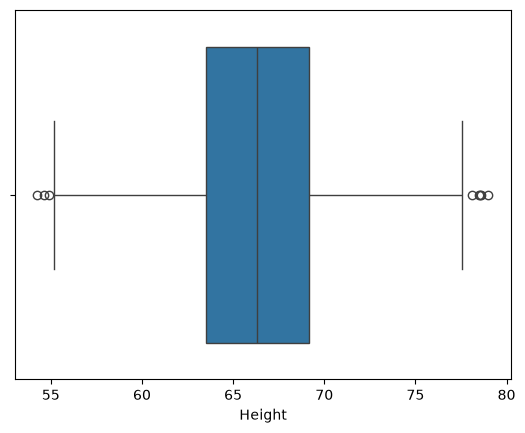

In [7]:
import seaborn as sns

sns.boxplot(x=df2["Height"])

<Axes: ylabel='Height'>

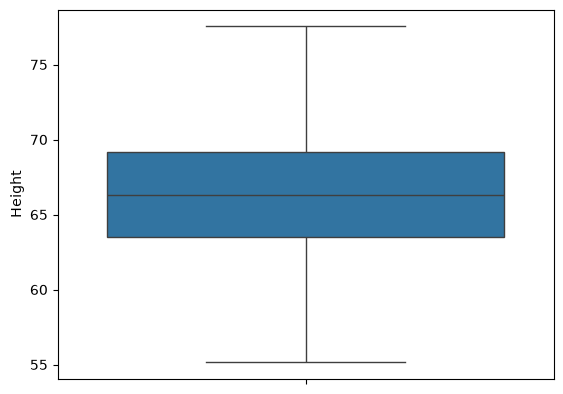

In [8]:
import numpy as np
# Identifikasi Q1 Q3
q1, q3 = np.percentile(df2['Height'], [25, 75])
# Hitung IQR
iqr = q3 - q1
# Cari lower dan upper bounds
lower_bound = q1 - (1.5 * iqr)
upper_bound = q3 + (1.5 * iqr)
# Hapus outliers
clean_data = df2[(df2['Height'] >= lower_bound)
& (df2['Height'] <= upper_bound)]
sns.boxplot(clean_data['Height'])

<Axes: ylabel='Weight'>

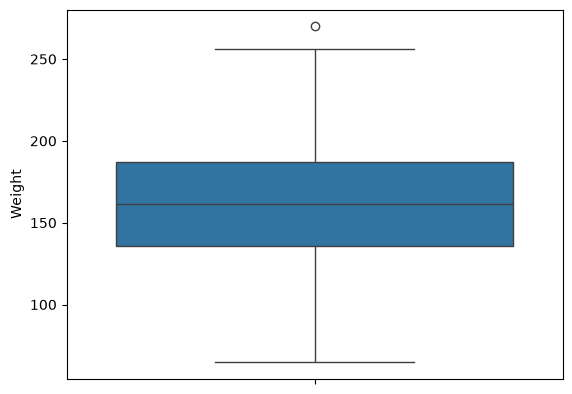

In [9]:
sns.boxplot(df2['Weight'])

<Axes: ylabel='Weight'>

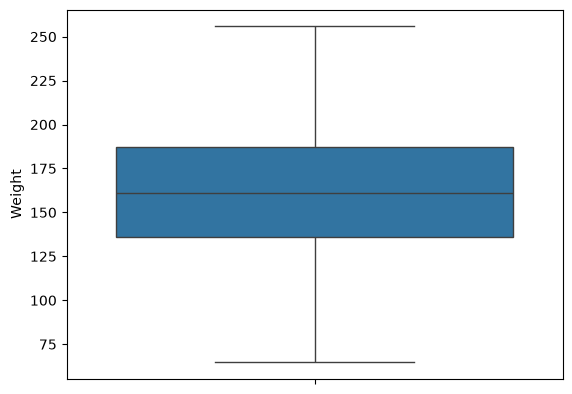

In [13]:
# Identifikasi Q1 Q3
q1, q3 = np.percentile(df2['Weight'], [25, 75])
# Hitung IQR
iqr = q3 - q1
# Cari lower dan upper bounds
lower_bound = q1 - (1.5 * iqr)
upper_bound = q3 + (1.5 * iqr)
# Hapus outliers
clean_data = df2[(df2['Weight'] >= lower_bound)
& (df2['Weight'] <= upper_bound)]
sns.boxplot(clean_data['Weight'])

C:\Users\acer\AppData\Local\Temp\ipykernel_24340\3698290487.py:11: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  axs[i].boxplot(df2[col], vert=False)
C:\Users\acer\AppData\Local\Temp\ipykernel_24340\3698290487.py:11: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  axs[i].boxplot(df2[col], vert=False)


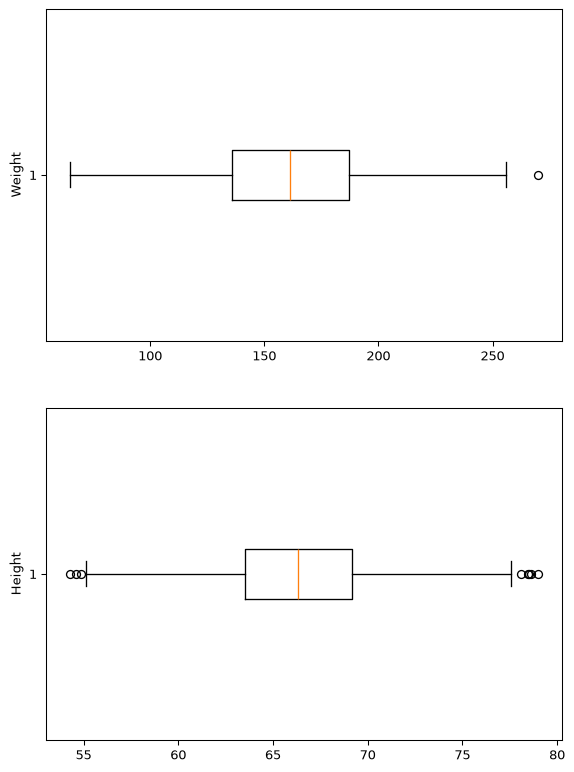

In [20]:
import matplotlib.pyplot as plt
# Membuat daftar kolom yang ingin dianalisis
columns_to_plot = ['Weight', 'Height']
# Memastikan kolom ada di dataset
columns_to_plot = [col for col in columns_to_plot if col in df2.columns]
# Membuat boxplot
fig, axs = plt.subplots(len(columns_to_plot),1,dpi=95,figsize=(7, 5 * len(columns_to_plot)))
if len(columns_to_plot) == 1:
    axs = [axs]
for i, col in enumerate(columns_to_plot):
    axs[i].boxplot(df2[col], vert=False)
    axs[i].set_ylabel(col)
plt.show()

C:\Users\acer\AppData\Local\Temp\ipykernel_24340\1597593676.py:28: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  axs[i].boxplot(clean_data[col], vert=False)
C:\Users\acer\AppData\Local\Temp\ipykernel_24340\1597593676.py:28: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  axs[i].boxplot(clean_data[col], vert=False)


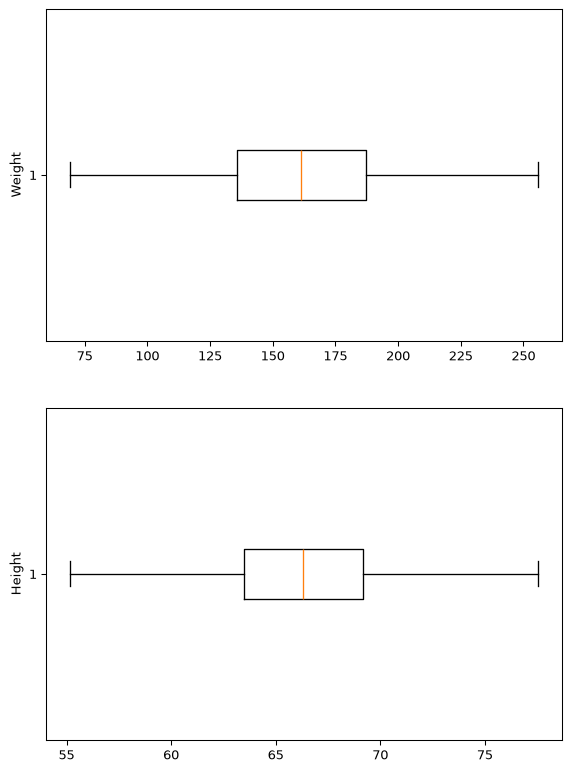

In [22]:
import numpy as np
import matplotlib.pyplot as plt
def remove_outliers_sequentially(df2, columns):
    df_cleaned = df2.copy()
    for col in columns:
        q1, q3 = np.percentile(df_cleaned[col], [25, 75])
        iqr = q3 - q1
        lower_bound = q1 - (1.5 * iqr)
        upper_bound = q3 + (1.5 * iqr)
        df_cleaned = df_cleaned[
            (df_cleaned[col] >= lower_bound) &
            (df_cleaned[col] <= upper_bound)
        ]
    return df_cleaned
# Terapkan fungsi untuk menghapus outliers dari "Height" dan "Weight"
clean_data = remove_outliers_sequentially(df2, ['Height', 'Weight'])
# Plot boxplots setelah menghapus outliers
columns_to_plot = ['Weight', 'Height']
fig, axs = plt.subplots(
    len(columns_to_plot),
    1,
    dpi=95,
    figsize=(7, 5 * len(columns_to_plot))
)
if len(columns_to_plot) == 1:
    axs = [axs]
for i, col in enumerate(columns_to_plot):
    axs[i].boxplot(clean_data[col], vert=False)
    axs[i].set_ylabel(col)
plt.show()

In [ ]:
%pip install scikit-learn

  Using cached scipy-1.18.1-cp314-cp314-win_amd64.whl.metadata (61 kB)
   ---------------------------------------- 0.0/8.4 MB ? eta -:--:--
   ---------------------------------------- 0.0/8.4 MB ? eta -:--:--
   - -------------------------------------- 0.3/8.4 MB ? eta -:--:--
   -- ------------------------------------- 0.5/8.4 MB 928.4 kB/s eta 0:00:09
   -- ------------------------------------- 0.5/8.4 MB 928.4 kB/s eta 0:00:09
   --- ------------------------------------ 0.8/8.4 MB 709.0 kB/s eta 0:00:11
   --- ------------------------------------ 0.8/8.4 MB 709.0 kB/s eta 0:00:11
   --- ------------------------------------ 0.8/8.4 MB 709.0 kB/s eta 0:00:11
   --- ------------------------------------ 0.8/8.4 MB 709.0 kB/s eta 0:00:11
   ----- ---------------------------------- 1.0/8.4 MB 500.6 kB/s eta 0:00:15
   ----- ---------------------------------- 1.0/8.4 MB 500.6 kB/s eta 0:00:15
   ----- ---------------------------------- 1.0/8.4 MB 500.6 kB/s eta 0:00:15
   ----- -----------

,Height,Weight
0,0.834804,0.925248
1,0.608669,0.499398
2,0.846549,0.769251
3,0.740332,0.808322
4,0.657774,0.735053


In [6]:
import numpy as np

def remove_outliers_sequentially(df2, columns):
    df_cleaned = df2.copy()

    for col in columns:
        q1, q3 = np.percentile(df_cleaned[col], [25, 75])
        iqr = q3 - q1

        lower_bound = q1 - (1.5 * iqr)
        upper_bound = q3 + (1.5 * iqr)

        df_cleaned = df_cleaned[
            (df_cleaned[col] >= lower_bound) &
            (df_cleaned[col] <= upper_bound)
        ]

    return df_cleaned

In [8]:
import pandas as pd

df2 = pd.read_csv("weight-height_outlier.csv")

In [9]:
clean_data = remove_outliers_sequentially(
    df2,
    ['Height', 'Weight']
)

In [10]:
clean_data.head()

,Gender,Height,Weight
0,Male,73.847017,241.893563
1,Male,68.781904,162.310473
2,Male,74.110105,212.740856
3,Male,71.730978,220.042470
4,Male,69.881796,206.349801


In [11]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler(feature_range=(0, 1))

numeric_cols = clean_data.select_dtypes(include=[np.number]).columns
non_numeric_cols = clean_data.select_dtypes(exclude=[np.number]).columns

rescaled_numeric = scaler.fit_transform(
    clean_data[numeric_cols]
)

rescaled_numeric

array([[0.83480376, 0.92524773],
       [0.6086688 , 0.49939825],
       [0.84654949, 0.76925146],
       ...,
       [0.38928431, 0.31834619],
       [0.61993463, 0.50764944],
       [0.30339752, 0.23901104]], shape=(9992, 2))

In [13]:
# Konversi kembali hasil scaling ke DataFrame
rescaled_df = pd.DataFrame(rescaled_numeric, columns=numeric_cols, index=clean_data)
# Gabungkan kembali dengan kolom non-numerik tanpa mengubah jumlah baris
final_df = pd.concat([clean_data[non_numeric_cols], rescaled_df], axis=1)
final_df

,Gender,Height,Weight
0,Male,NaN,NaN
1,Male,NaN,NaN
2,Male,NaN,NaN
3,Male,NaN,NaN
4,Male,NaN,NaN
...,...,...,...
"(Female, 66.1726521477708, 136.777454183235)",NaN,0.492177,0.362771
"(Female, 67.067154649054, 170.867905890713)",NaN,0.532113,0.545189
"(Female, 63.8679922137577, 128.475318784122)",NaN,0.389284,0.318346
"(Female, 69.0342431307346, 163.852461346571)",NaN,0.619935,0.507649


In [ ]:
#Tugas Handling missing value dari dataset 'Titanic-Dataset.csv'
import pandas as pd
import numpy as np

# Membaca dataset
df = pd.read_csv("Titanic-Dataset.csv")

# Melihat jumlah missing value
print("Missing value sebelum ditangani:")
print(df.isnull().sum())

Missing value sebelum ditangani:
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64


In [15]:
# Membuat salinan dataset
df_clean = df.copy()

# Mengisi missing value pada Age dengan median
df_clean['Age'] = df_clean['Age'].fillna(df_clean['Age'].median())

# Mengisi missing value pada Embarked dengan mode
df_clean['Embarked'] = df_clean['Embarked'].fillna(df_clean['Embarked'].mode()[0])

# Mengisi missing value pada Fare dengan median jika ada
if 'Fare' in df_clean.columns:
    df_clean['Fare'] = df_clean['Fare'].fillna(df_clean['Fare'].median())

# Menghapus Cabin karena terlalu banyak missing value
if 'Cabin' in df_clean.columns:
    df_clean = df_clean.drop(columns=['Cabin'])

# Mengecek kembali missing value
df_clean.isnull().sum()

PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
dtype: int64

In [ ]:
#Tugas Handling Outliers — diabetes.csv
df2 = pd.read_csv("diabetes.csv")

df2.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [17]:
df2.columns

Index(['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin',
       'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome'],
      dtype='str')

C:\Users\acer\AppData\Local\Temp\ipykernel_21380\3346464971.py:13: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  axs[i].boxplot(df2[col], vert=False)
C:\Users\acer\AppData\Local\Temp\ipykernel_21380\3346464971.py:13: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  axs[i].boxplot(df2[col], vert=False)
C:\Users\acer\AppData\Local\Temp\ipykernel_21380\3346464971.py:13: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  axs[i].boxplot(df2[col], vert=False)


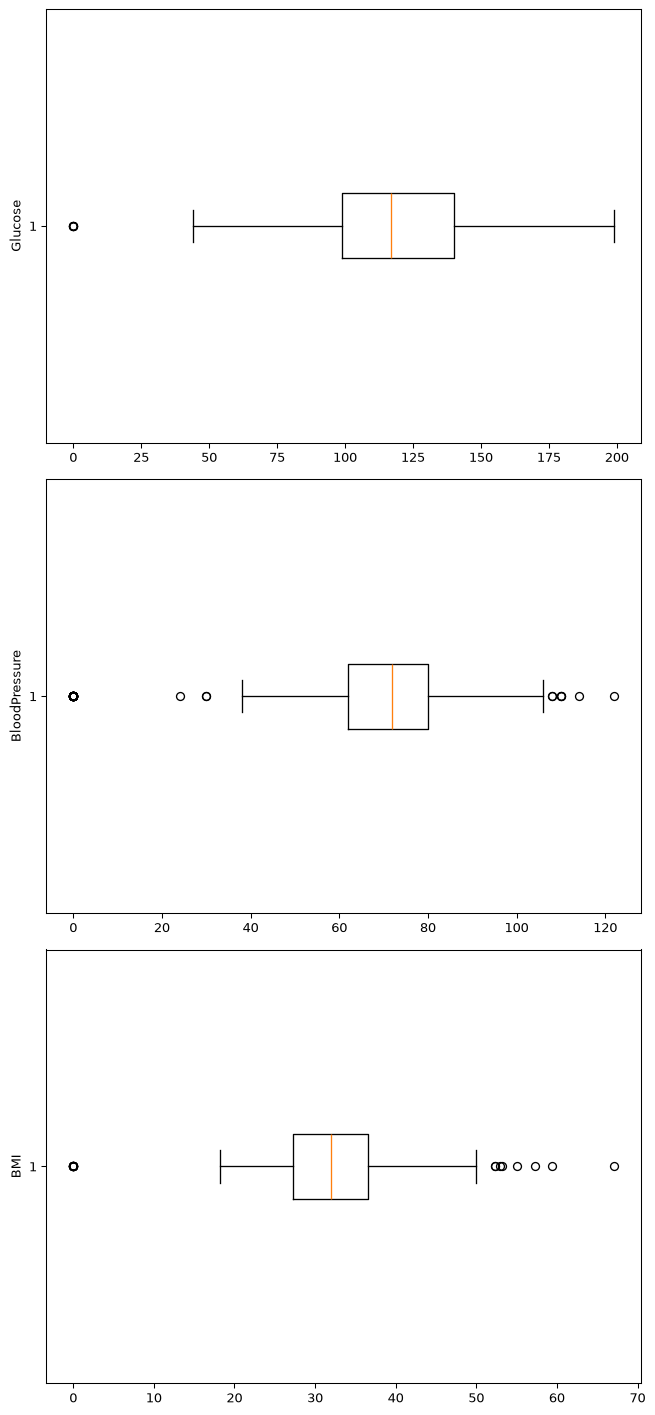

In [18]:
import matplotlib.pyplot as plt

columns_to_plot = ['Glucose', 'BloodPressure', 'BMI']

fig, axs = plt.subplots(
    len(columns_to_plot),
    1,
    dpi=95,
    figsize=(7, 5 * len(columns_to_plot))
)

for i, col in enumerate(columns_to_plot):
    axs[i].boxplot(df2[col], vert=False)
    axs[i].set_ylabel(col)

plt.tight_layout()
plt.show()

In [ ]:
#Menghapus Outlier dengan IQR
def remove_outliers_sequentially(df, columns):
    df_cleaned = df.copy()

    for col in columns:
        q1, q3 = np.percentile(df_cleaned[col], [25, 75])
        iqr = q3 - q1

        lower_bound = q1 - (1.5 * iqr)
        upper_bound = q3 + (1.5 * iqr)

        df_cleaned = df_cleaned[
            (df_cleaned[col] >= lower_bound) &
            (df_cleaned[col] <= upper_bound)
        ]

    return df_cleaned

In [20]:
clean_diabetes = remove_outliers_sequentially(
    df2,
    ['Glucose', 'BloodPressure', 'BMI']
)

print("Jumlah data sebelum menghapus outlier:", len(df2))
print("Jumlah data setelah menghapus outlier:", len(clean_diabetes))

Jumlah data sebelum menghapus outlier: 768
Jumlah data setelah menghapus outlier: 709


C:\Users\acer\AppData\Local\Temp\ipykernel_21380\3833416268.py:9: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  axs[i].boxplot(clean_diabetes[col], vert=False)
C:\Users\acer\AppData\Local\Temp\ipykernel_21380\3833416268.py:9: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  axs[i].boxplot(clean_diabetes[col], vert=False)
C:\Users\acer\AppData\Local\Temp\ipykernel_21380\3833416268.py:9: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  axs[i].boxplot(clean_diabetes[col], vert=False)


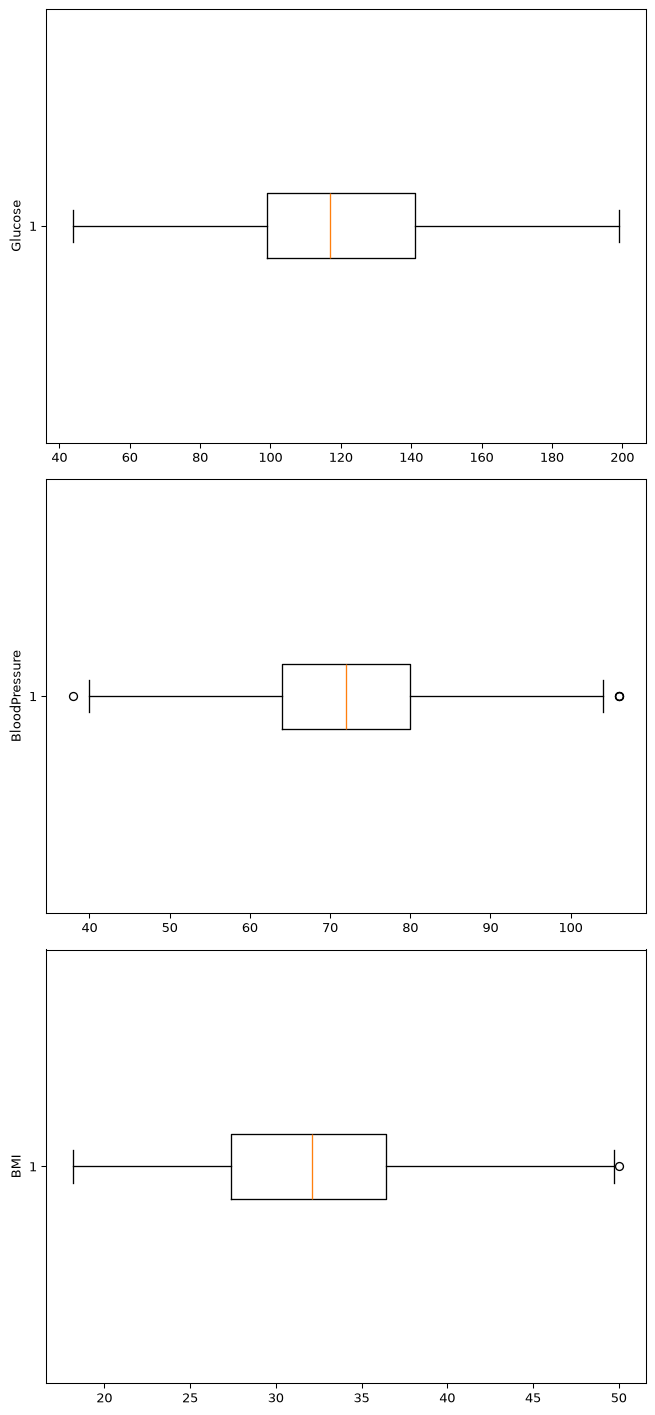

In [21]:
fig, axs = plt.subplots(
    len(columns_to_plot),
    1,
    dpi=95,
    figsize=(7, 5 * len(columns_to_plot))
)

for i, col in enumerate(columns_to_plot):
    axs[i].boxplot(clean_diabetes[col], vert=False)
    axs[i].set_ylabel(col)

plt.tight_layout()
plt.show()